# Data exploration — Egyptian Hieroglyph dataset

Goal: understand the raw dataset in `data/raw/` before writing any
training code. We want to know: how many classes, how balanced are they,
what do the images actually look like, and what train/val/test split
strategy makes sense given what we find.

In [1]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

DATA_ROOT = Path("..") / "data" / "raw"
assert DATA_ROOT.exists(), f"Expected dataset at {DATA_ROOT.resolve()}"

## Class distribution

Each subfolder of `data/raw/` is a Gardiner sign class. Count images per class.

In [2]:
class_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
counts = Counter()
for cls_dir in class_dirs:
    n = sum(1 for f in cls_dir.iterdir() if f.is_file())
    counts[cls_dir.name] = n

df = pd.DataFrame({"class": list(counts.keys()), "count": list(counts.values())})
df = df.sort_values("count", ascending=False).reset_index(drop=True)

print(f"Classes: {len(df)}")
print(f"Total images: {df['count'].sum()}")
print(df["count"].describe())

Classes: 171
Total images: 4031
count    171.000000
mean      23.573099
std       58.864842
min        1.000000
25%        2.000000
50%        5.000000
75%       15.000000
max      448.000000
Name: count, dtype: float64


In [3]:
# Classes with very few images are a real risk for stratified train/val/test
# splitting later (need at least 1 sample per split, ideally more).
print("Classes with fewer than 5 images:")
print(df[df["count"] < 5])

Classes with fewer than 5 images:
    class  count
87     U7      4
88     F4      4
89     M3      4
90    W19      4
91    F26      4
..    ...    ...
166   V25      1
167   U35      1
168   W15      1
169    X6      1
170    Y1      1

[84 rows x 2 columns]


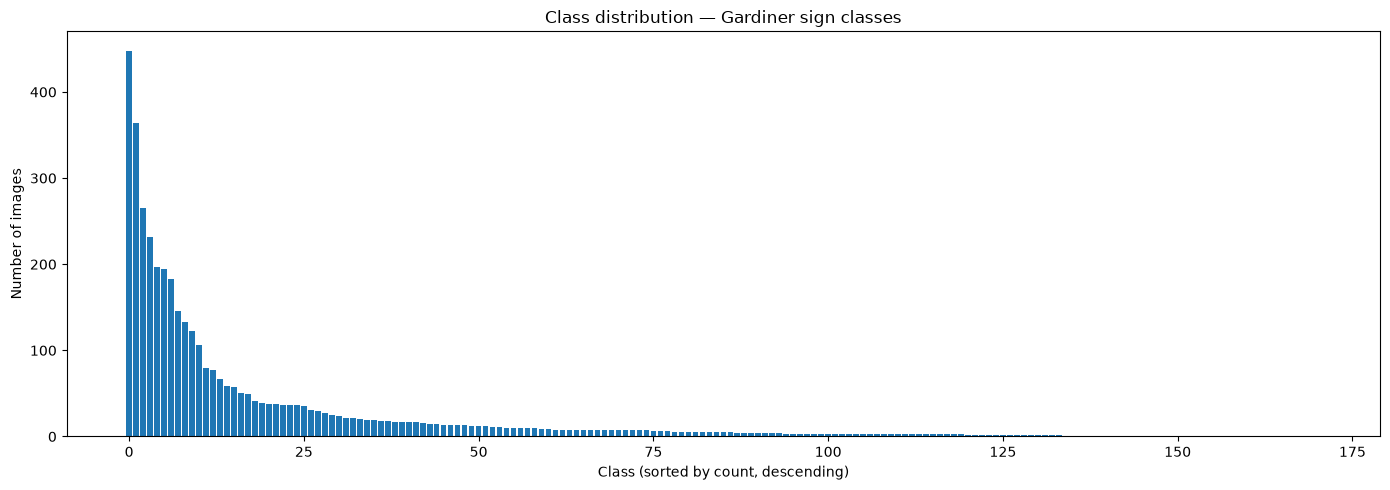

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(df)), df["count"])
ax.set_xlabel("Class (sorted by count, descending)")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution — Gardiner sign classes")
plt.tight_layout()
plt.show()

## Sample images

Look at actual glyphs, not just counts — sanity check that images look like
what we expect (small grayscale glyph crops).

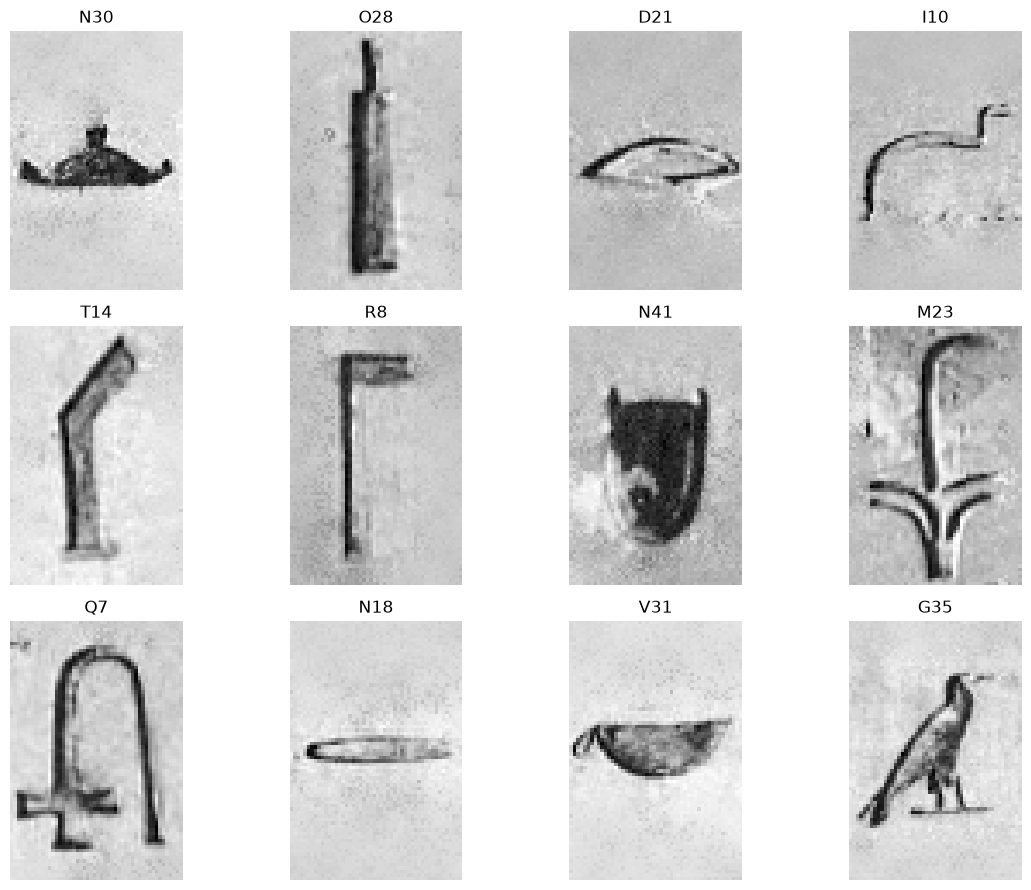

In [5]:
random.seed(0)
sample_classes = random.sample(class_dirs, 12)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, cls_dir in zip(axes.flat, sample_classes):
    img_path = next(f for f in cls_dir.iterdir() if f.is_file())
    img = Image.open(img_path)
    ax.imshow(img, cmap="gray")
    ax.set_title(cls_dir.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Image size / format consistency

Check whether all images share the documented spec (75x50 grayscale), or if
there's variation we need to handle in the transforms.

In [6]:
sizes = Counter()
modes = Counter()
for cls_dir in class_dirs:
    for f in cls_dir.iterdir():
        if not f.is_file():
            continue
        with Image.open(f) as img:
            sizes[img.size] += 1
            modes[img.mode] += 1

print("Sizes:", sizes.most_common(5))
print("Modes:", modes.most_common(5))

Sizes: [((50, 75), 4031)]
Modes: [('L', 4031)]


## Decisions for the training pipeline

- **Input size:** resize to 224x224 to match ResNet18's expected input
  (pretrained on ImageNet at that resolution).
- **Normalization:** ImageNet mean/std, since we're fine-tuning an
  ImageNet-pretrained backbone — grayscale images will be replicated to 3
  channels first.
- **Split strategy:** a plain 3-way stratified split (`sklearn.train_test_split`)
  fails outright here — 37 of 171 classes have only 1 image, and you can't
  divide 1 image across train/val/test. Instead we use a custom per-class
  splitter (`src/hieroglyph/data/split.py`): classes with fewer than 3 images
  go entirely into train (not enough data to hold any back for evaluation);
  classes with 3+ images get a 70/15/15 split with at least 1 image
  guaranteed in val and test. This means the model will never be validated
  on those ~37 rarest signs — a real limitation, stated here rather than
  hidden, with testing against a different dataset later noted as a
  possible way to evaluate them eventually.


In [7]:
import sys

sys.path.insert(0, str(Path("..") / "src"))
from hieroglyph.data.split import samples_by_class_from_dir, split_dataset

samples_by_class = samples_by_class_from_dir(DATA_ROOT)
result = split_dataset(samples_by_class, val_frac=0.15, test_frac=0.15, min_images_to_hold_out=3)

rare_classes = [c for c, imgs in samples_by_class.items() if len(imgs) < 3]
print(f"train: {len(result.train)}  val: {len(result.val)}  test: {len(result.test)}")
print(f"Classes routed entirely to train (fewer than 3 images): {len(rare_classes)}")

val_classes = {label for _, label in result.val}
test_classes = {label for _, label in result.test}
print(f"Classes represented in val: {len(val_classes)}/{len(samples_by_class)}")
print(f"Classes represented in test: {len(test_classes)}/{len(samples_by_class)}")

train: 2791  val: 620  test: 620
Classes routed entirely to train (fewer than 3 images): 51
Classes represented in val: 120/171
Classes represented in test: 120/171
